# 1.Import Library

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern
import seaborn as sns
import pandas as pd

import cv2

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.preprocessing import image

import pickle
from tqdm import tqdm
import time
import os
from pathlib import Path
import kagglehub

# 2. Data Preprocessing

In [59]:
dataset_path = r"C:\Users\ADMIN\Downloads\archive\raw-img"

print(f"Đường dẫn dataset: {dataset_path}")

# List các thư mục trong raw-img
dataset_contents = sorted([d for d in os.listdir(dataset_path) 
                          if os.path.isdir(os.path.join(dataset_path, d))])
print(f"\nTìm thấy {len(dataset_contents)} thư mục trong '{dataset_path}':")
for folder in dataset_contents:
    num_files = len([f for f in os.listdir(os.path.join(dataset_path, folder)) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder:15} - {num_files:4d} files")

Đường dẫn dataset: C:\Users\ADMIN\Downloads\archive\raw-img

Tìm thấy 10 thư mục trong 'C:\Users\ADMIN\Downloads\archive\raw-img':
  cane            - 4863 files
  cavallo         - 2623 files
  elefante        - 1446 files
  farfalla        - 2112 files
  gallina         - 3098 files
  gatto           - 1668 files
  mucca           - 1866 files
  pecora          - 1820 files
  ragno           - 4821 files
  scoiattolo      - 1862 files


In [60]:
translation_table = {
    "cane": "dog",
    "cavallo": "horse", 
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "scoiattolo": "squirrel",
    "ragno": "spider"
}

# Kiểm tra bản dịch
print("Bảng dịch tên thư mục (Italian -> English):")
for ita, eng in translation_table.items():
    print(f"{ita:12} -> {eng}")

Bảng dịch tên thư mục (Italian -> English):
cane         -> dog
cavallo      -> horse
elefante     -> elephant
farfalla     -> butterfly
gallina      -> chicken
gatto        -> cat
mucca        -> cow
pecora       -> sheep
scoiattolo   -> squirrel
ragno        -> spider


In [61]:
def load_dataset(dataset_path, translation_table):
        """
        Load images from directory structure:
        dataset_path/
            cavallo/
            pecora/
            elefante/
            ...
        """

        image_paths = []
        labels = []

        # Iterate through the directories in raw_img_path (each directory is a label)
        for label in os.listdir(dataset_path):
            label_path = os.path.join(dataset_path, label)
            # Check if it's a directory
            if os.path.isdir(label_path):
                # Iterate through the files in the label directory
                for image_file in tqdm(os.listdir(label_path), desc=f'Loading {translation_table[label]}: '):
                    image_path = os.path.join(label_path, image_file)
                    # Check if it's a file
                    if os.path.isfile(image_path):
                        image_paths.append(image_path)
                        labels.append(translation_table[label])

        # Create a pandas DataFrame
        df = pd.DataFrame({'image_path': image_paths, 'label': labels})

        return df

In [62]:
# Load the VGG16 model with pre-trained ImageNet weights and including the top layers
base_model = VGG16(weights='imagenet', include_top=True)
# Create a new model that outputs from the 'fc2' layer
model_fc2 = tf.keras.Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

In [63]:
def extract_cnn_features(image_paths, batch_size=32, img_size=(224, 224)):
      """Extract CNN features in batches to save memory from a DataFrame containing 'image_data' column"""
      print("Extracting CNN features using VGG16...")
      print(f"  Architecture: VGG16 (ImageNet pre-trained)")
      print(f"  Layer: fc2 (last fully connected layer before output)")
      print(f"  Parameters: include_top=True")
      print(f"  Batch size: {batch_size}")

      features = []
      current_batch_images = []

      # Check for GPU availability
      gpus = tf.config.list_physical_devices('GPU')
      if gpus:
          device_name = '/GPU:0'
          print("  Using GPU for CNN feature extraction.")
      else:
          device_name = '/CPU:0'
          print("  Using CPU for CNN feature extraction.")

      with tf.device(device_name):
          # Iterate over the 'image_data' column of the DataFrame
          for i, path in enumerate(tqdm(image_paths, desc='Extracting VGG16 Features: ')):
              img_array_data = cv2.imread(path)
              # Fix: Pass img_size as a tuple (width, height)
              img_array_data = cv2.resize(img_array_data, img_size)
              img_rgb = cv2.cvtColor(img_array_data, cv2.COLOR_BGR2RGB)
              img_preprocessed = vgg_preprocess(np.expand_dims(img_rgb, axis=0)) # Add batch dimension for preprocessing

              current_batch_images.append(img_preprocessed[0]) # Append the image without the extra batch dimension

              # If batch is full or it's the last image
              if len(current_batch_images) == batch_size or i == len(image_paths) - 1:
                  batch_tensor = np.array(current_batch_images) # Convert list of images to a single batch tensor
                  batch_features = model_fc2.predict(batch_tensor, verbose=0)
                  features.extend(batch_features)
                  current_batch_images = [] # Reset batch

      features = np.array(features)
      print(f"  Feature dimension: {features.shape[1]} per image")
      print(f"  Total features extracted: {features.shape[0]}")
      return features

In [65]:
data = load_dataset(dataset_path, translation_table)

Loading squirrel: 100%|██████████| 1862/1862 [00:00<00:00, 25762.31it/s]


In [21]:
data.head()

,image_path,label
0,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog
1,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog
2,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog
3,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog
4,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog


In [ ]:
encoder_path = r"C:\Users\ADMIN\CS231\modules\vgg16_label_encoder.pkl"

os.makedirs(os.path.dirname(encoder_path), exist_ok=True)

if not os.path.exists(encoder_path):

    encoder = LabelEncoder()
    data['label_encoded'] = encoder.fit_transform(data['label'])

    os.makedirs(os.path.dirname(encoder_path), exist_ok=True)

    with open(encoder_path, 'wb') as f:
        pickle.dump(encoder, f)

    print("LabelEncoder đã được tạo và lưu!")

else:
    with open(encoder_path, 'rb') as f:
        encoder = pickle.load(f)

    data['label_encoded'] = encoder.transform(data['label'])

    print("Đã load LabelEncoder từ file!")

Đã load LabelEncoder từ file!


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [34]:
data.head()

,image_path,label,label_encoded
0,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog,4
1,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog,4
2,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog,4
3,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog,4
4,C:\Users\ADMIN\Downloads\archive\raw-img\cane\...,dog,4


# 3. Feature Extraction (VGG16)

In [ ]:
features_path = r"C:\Users\ADMIN\CS231\modules\vgg16_features.pkl"

os.makedirs(os.path.dirname(features_path), exist_ok=True)

if not os.path.exists(features_path):

    features = extract_cnn_features(data['image_path'])
    print(features.shape)

    # Save
    with open(features_path, 'wb') as f:
        pickle.dump(features, f)

    print(f"VGG16 features saved to '{features_path}'")

else:
    features = pickle.load(open(features_path, 'rb'))
    print("Loaded saved features")

Extracting CNN features using VGG16...
  Architecture: VGG16 (ImageNet pre-trained)
  Layer: fc2 (last fully connected layer before output)
  Parameters: include_top=True
  Batch size: 32
  Using CPU for CNN feature extraction.


Extracting VGG16 Features: 100%|██████████| 26179/26179 [51:15<00:00,  8.51it/s]  


  Feature dimension: 4096 per image
  Total features extracted: 26179
(26179, 4096)
VGG16 features saved to './vgg16_features.pkl'


In [ ]:
X = features
y = data["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

scaler_filename = r"C:\Users\ADMIN\CS231\modules\vgg16_scaler.pkl"

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

os.makedirs(os.path.dirname(scaler_filename), exist_ok=True)

with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Scaler saved to {scaler_filename}")

print("\nData scaled successfully.")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

Training data shape: (20943, 4096)
Testing data shape: (5236, 4096)
Scaler saved to C:\Users\ADMIN\CS231.Q11\modules\vgg16_scaler.pkl

Data scaled successfully.
Scaled training data shape: (20943, 4096)
Scaled testing data shape: (5236, 4096)


# 4. Feature Reduction

### PCA

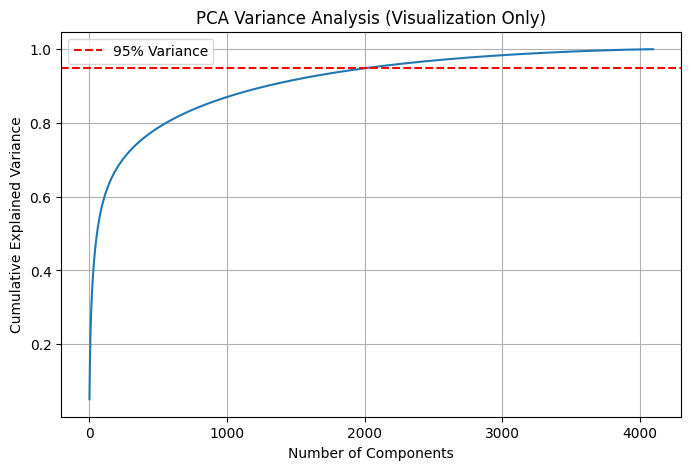

In [68]:
pca_vis = PCA().fit(X_train_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_vis.explained_variance_ratio_))

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title("PCA Variance Analysis (Visualization Only)")

plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()
plt.show()

In [ ]:
pca_path = r"C:\Users\ADMIN\CS231\modules\vgg16_pca.pkl"
os.makedirs(os.path.dirname(pca_path), exist_ok=True)

pca = PCA(n_components=500)

if not os.path.exists(pca_path):

    print("Fitting PCA...")

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    os.makedirs(os.path.dirname(pca_path), exist_ok=True)

    with open(pca_path, 'wb') as f:
        pickle.dump(pca, f)

    print("PCA saved")

else:
    with open(pca_path, 'rb') as f:
        pca = pickle.load(f)

    # chỉ transform lại
    X_train_pca = pca.transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

print("\nSHAPE AFTER PCA:")
print(f"Train: {X_train_pca.shape}")
print(f"Test : {X_test_pca.shape}")

print(f"\nExplained variance: {pca.explained_variance_ratio_.sum():.4f}")

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



SHAPE AFTER PCA:
Train: (20943, 500)
Test : (5236, 500)

Explained variance: 0.7849


# 5. Training

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = r"C:\Users\ADMIN\CS231\modules\vgg16_random_forest_model.pkl"

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'class_weight': ['balanced']
}

# Instantiate a RandomForestClassifier object
rf_clf = RandomForestClassifier(random_state=42)

# Instantiate GridSearchCV
# cv=2 for cross-validation folds
# verbose=2 to display progress
# n_jobs=-1 to use all available CPU cores
grid_search_rf = GridSearchCV(rf_clf, param_grid_rf, cv=2, verbose=2, n_jobs=-1)

try:
  if os.path.exists(random_forest_model):
    grid_search_rf = pickle.load(open(random_forest_model, 'rb'))
    print(f"Successfully loaded existing GridSearchCV object from '{random_forest_model}'")
  else:
    # If the file doesn't exist, we need to train a new model
    raise FileNotFoundError # This will be caught by the except block
except (EOFError, FileNotFoundError, pickle.UnpicklingError) as e:
  print(f"Model file '{random_forest_model}' not found or is corrupted (Error: {e}). Training and saving a new model...")
  if os.path.exists(random_forest_model):
    os.remove(random_forest_model) # Delete the corrupted file

  print("Starting GridSearchCV for Random Forest to find optimal hyperparameters...")
  # Fit GridSearchCV to the PCA-transformed training data
  grid_search_rf.fit(X_train_pca, y_train)

  print("Random Forest GridSearchCV completed.")
  print(f"Best parameters found by Random Forest GridSearchCV: {grid_search_rf.best_params_}")

  with open(random_forest_model, 'wb') as file:
    pickle.dump(grid_search_rf, file) # Save the entire GridSearchCV object
  print(f"Random Forest GridSearchCV object saved to '{random_forest_model}'")

Successfully loaded existing GridSearchCV object from 'C:\Users\ADMIN\CS231.Q11\modules\vgg16_random_forest_model.pkl'


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to 

Best parameters found by Random Forest GridSearchCV: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 300}
Random Forest Accuracy Score: 0.9605

Random Forest Classification Report:
              precision    recall  f1-score   support

   butterfly       0.97      0.98      0.98       422
         cat       0.97      0.93      0.95       334
     chicken       0.98      0.97      0.98       620
         cow       0.92      0.92      0.92       373
         dog       0.96      0.96      0.96       973
    elephant       0.98      0.97      0.97       289
       horse       0.93      0.93      0.93       525
       sheep       0.92      0.92      0.92       364
      spider       0.98      0.99      0.99       964
    squirrel       0.96      0.99      0.97       372

    accuracy                           0.96      5236
   macro avg       0.96      0.96      0.96      5236
weighted avg       0.96      0.96      0.96      5236


Random Forest Confusion Matrix:


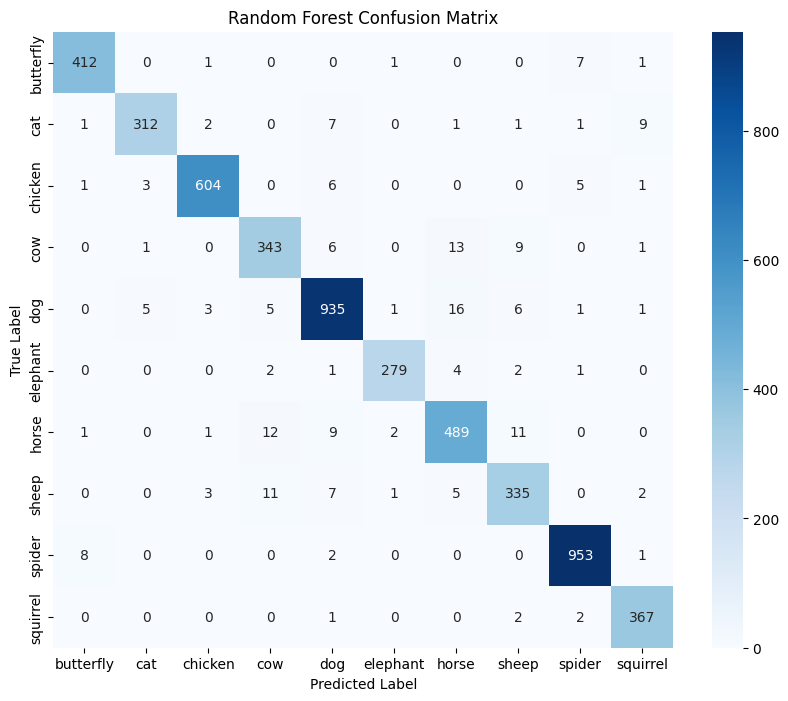

In [72]:
y_pred_rf = grid_search_rf.best_estimator_.predict(X_test_pca)

print(f"Best parameters found by Random Forest GridSearchCV: {grid_search_rf.best_params_}")
print(f"Random Forest Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

print("\nRandom Forest Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()